In [3]:
import numpy as np
import torch

import os
from tqdm import tqdm
import sys
sys.path.append("..")


In [4]:
os.environ["CUDA_VISIBLE_DEVICES"]=str(6)

In [5]:
train_data='gsv'
method='crica'
dataset='eynsham'
lr=1e-7
num="8" 
patience=None
saved_path_log= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
saved_path_model= f"../logs/best_model_{train_data}_{method}/{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
# saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
logfile=torch.load(saved_path_log)
args=logfile['args']
original_model=True

In [4]:
method="crica"

if method=="boq":
    image_size=[322,322]
    descriptors_dimension = 12288

        
    model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name="dinov2", output_dim=12288)
#     for param in model.backbone.named_parameters():
#         if param[1].requires_grad:
#             param[1].requires_grad=False

    
elif method == "crica":
    image_size=[224,224]
    descriptors_dimension = 10752
    model=torch.hub.load("Lu-Feng/CricaVPR", "trained_model")
    args.features_dim=descriptors_dimension
elif method == "salad":
    image_size=[322,322]
    descriptors_dimension=8448
    features_dim=descriptors_dimension
    model = torch.hub.load("serizba/salad", "dinov2_salad")
    
    
if not original_model:
    state_dict=torch.load(saved_path_model)["model_state_dict"]
    model.load_state_dict()

Using cache found in /home/osverburg/.cache/torch/hub/Lu-Feng_CricaVPR_main
xFormers not available
xFormers not available


In [6]:
wanted_datasets=["amstertime","nordland","eynsham","sped"]
# wanted_dataset2="amstertime"

In [11]:
from CricaVPR.dataloaders.train.GSVCitiesDataset import GSVCitiesDataset
from datasets_ws import BaseDataset
import torchvision.transforms as T
from torch.utils.data.dataset import Subset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

In [7]:
TRAIN_CITIES = [
    'Bangkok',
    'BuenosAires',
    'LosAngeles',
    'MexicoCity',
    'OSL', # refers to Oslo
    'Rome',
    'Barcelona',
    'Chicago',
    'Madrid',
    'Miami',
    'Phoenix',
    'TRT', # refers to Toronto
    'Boston',
    'Lisbon',
    'Medellin',
    'Minneapolis',
    'PRG', # refers to Prague
    'WashingtonDC',
    'Brussels',
    'London',
    'Melbourne',
    'Osaka',
    'PRS', # refers to Paris
]
base_transform = T.Compose([
    T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_ds = GSVCitiesDataset(
                cities=TRAIN_CITIES,
                img_per_place=1,
                min_img_per_place=1,
                random_sample_from_each_place=0,
                transform=base_transform)
train_dataloader=torch.utils.data.DataLoader(dataset=train_ds, num_workers=4,
                                 batch_size=16,
                                 pin_memory=True,
                                 drop_last=False)



In [8]:
dataset_list=[]
features_lists=[]
features_lists_lengths=[]
for dataset_name in wanted_datasets:
    print(f"extracting features of {dataset_name}")
    eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
    test_method=args.test_method
    model = model.eval()
    with torch.no_grad():
        print("Extracting database features for evaluation")
        # For database use "hard_resize", although it usually has no effect because database images have same resolution
        eval_ds.test_method = "hard_resize"
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, num_workers=args.num_workers,
                                         batch_size=args.infer_batch_size, pin_memory=(args.device == "cuda"))
        
        if test_method == "nearest_crop" or test_method == 'maj_voting':
            all_features = np.empty((5 * eval_ds.queries_num + eval_ds.database_num, args.features_dim), dtype="float32")
        else:
            all_features = np.empty((len(eval_ds), args.features_dim), dtype="float32")

        for inputs, indices in tqdm(database_dataloader):
            features = model(inputs.to(args.device))
            features = features.cpu().numpy()
            all_features[indices.numpy(), :] = features
        
        print("Extracting queries features for evaluation")
        queries_infer_batch_size = 1 if test_method == "single_query" else args.infer_batch_size
        eval_ds.test_method = test_method
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, num_workers=args.num_workers,
                                        batch_size=queries_infer_batch_size, pin_memory=(args.device == "cuda"))
        for inputs, indices in tqdm(queries_dataloader):
            if test_method == "five_crops" or test_method == "nearest_crop" or test_method == 'maj_voting':
                inputs = torch.cat(tuple(inputs))  # shape = 5*bs x 3 x 480 x 480
                
            if (args.augments or eval_ds.dataset_name=="amstertime") and not eval_ds.dataset_name=="nordland" and not args.use_val_augments:
                inputs=combining_methods(inputs)
            
            features = model(inputs.to(args.device))
            if test_method == "five_crops":  # Compute mean along the 5 crops
                features = torch.stack(torch.split(features, 5)).mean(1)
            features = features.cpu().numpy()
            
            if test_method == "nearest_crop" or test_method == 'maj_voting':  # store the features of all 5 crops
                start_idx = eval_ds.database_num + (indices[0] - eval_ds.database_num) * 5
                end_idx = start_idx + indices.shape[0] * 5
                indices = np.arange(start_idx, end_idx)
                all_features[indices, :] = features
            else:
                all_features[indices.numpy(), :] = features
    
    queries_features = all_features[eval_ds.database_num:]
    database_features = all_features[:eval_ds.database_num]
    np.save(f"{dataset_name}_queries.npy",queries_features)
    np.save(f"{dataset_name}_database.npy",database_features)
#     features_lists.append(queries_features)
#     features_lists.append(database_features)
#     features_lists_lengths.append(len(queries_features))
#     features_lists_lengths.append(len(database_features))
    

extracting features of amstertime
Extracting database features for evaluation


100%|██████████| 77/77 [00:27<00:00,  2.79it/s]


Extracting queries features for evaluation


100%|██████████| 77/77 [00:22<00:00,  3.35it/s]


extracting features of nordland
Extracting database features for evaluation


100%|██████████| 1725/1725 [08:29<00:00,  3.38it/s]


Extracting queries features for evaluation


100%|██████████| 1725/1725 [11:14<00:00,  2.56it/s]


OSError: Not enough free space to write 1186676736 bytes

In [ ]:
features_lists=np.array(features_lists)
features_lists_lenghts=np.array(features_lists_lenghts)
np.save("all_test_features_crica.npy",features_lists)
np.save("all_test_lenghts.npy",features_lists_lenghts)

In [25]:
all_features = []
with torch.no_grad():
    
    for inputs, indices in tqdm(train_dataloader):
        inputs=inputs.squeeze()
#         print(inputs.shape,indices,all_features.shape)
        features = model(inputs.to(args.device))
        features = features.cpu().numpy()
#         print(features.shape)
        all_features.append(features)
    all_features=np.array(all_features)
    features_lists.append(all_features)
    features_lists_lengths.append(len(all_features))

 56%|█████▌    | 2257/4025 [07:00<05:29,  5.37it/s]


KeyboardInterrupt: 

In [ ]:
features_lists=np.array(features_lists)
np.save("all_features_crica.npy",features_lists)
np.save("all_lenghts.npy",features_lists_lenghts)

In [10]:
y=0
x=0
backbone_num=0
backbone_trainable=0
agg_trainable=0
agg_num=0
if method == "crica":
    for name, param in model.module.backbone.named_parameters():
        if "adapter" not in name:
            param.requires_grad = False
if method == "salad":
    for blk in model.backbone.model.blocks[:-model.backbone.num_trainable_blocks]:
    #     print(blk)
        for param in blk.parameters():
            param.requires_grad=False
model.train()
# print(model.module.backbone.blocks[5].attn)

for param in model.named_parameters():
#     print(param[0])
    y+=param[1].numel()
    if "backbone" in param[0]:
        backbone_num+=param[1].numel()
    if "backbone" not in param[0]:
        agg_num+=param[1].numel()
    if param[1].requires_grad and "backbone" in param[0]:
        backbone_trainable+=param[1].numel()
    
    if param[1].requires_grad and "backbone" not in param[0]:
        agg_trainable+=param[1].numel()
    
    if param[1].requires_grad:
#         print(param[0])
        x+=param[1].numel()


print(f"model: {method} with {y:.3e} parameters is trainable on {x:.3e} parameters the backbone has {backbone_num:.3e} parameter and {backbone_trainable:.3e} are trainable")
print(f"aggregator has {agg_num:.3e} parameter and is trainable on {agg_trainable:.3e}")

model: salad with 8.799e+07 parameters is trainable on 3.128e+07 parameters the backbone has 8.658e+07 parameter and 2.987e+07 are trainable
aggregator has 1.411e+06 parameter and is trainable on 1.411e+06


In [39]:
image_size = (322,322)
args.image_size= (322,322)
args.resize=args.image_size
eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name="amstertime",split='test')
    
database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
database_dataloader = DataLoader(dataset=database_subset_ds, num_workers=args.num_workers,
                                         batch_size=1, pin_memory=(args.device == "cuda"))




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


NameError: name 'x' is not defined

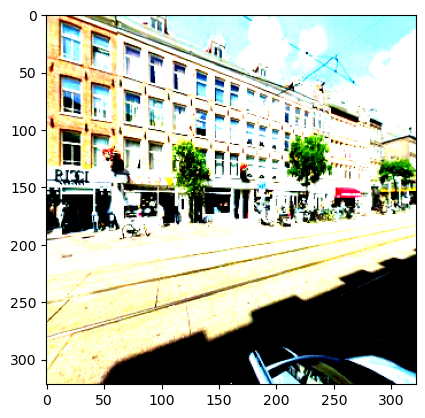

In [47]:
for img,index in database_dataloader:
    img=img[0]
    plt.imshow((img.permute(1,2,0)))
    x()